# **Importing the dataset**

In [1]:
import pandas as pd
import io
#from google.colab import files
#uploaded = files.upload()

In [2]:
pima = pd.read_csv(r"C:\Users\ADMIN\Desktop\tns\python\Decision_Tree_(Indian_Diabetes_Data)\pima-indians-diabetes.csv")

In [3]:
pima.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**Data Dictionary**

In [4]:
#pregnant = Number of times pregnant
#glucose = Plasma glucose concentration a 2 hours in an oral glucose tolerance test
#bp = Diastolic blood pressure (mm Hg)
#skin = Triceps skin fold thickness (mm)
#insulin = 2-Hour serum insulin (mu U/ml)
#BMI = Body mass index (weight in kg/(height in m)^2)
#pedigree = Diabetes pedigree function
#age = Age (years)
#label = Class variable (1:tested positive for diabetes, 0: tested negative for diabetes)

In [5]:
feature_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
X = pima[feature_cols] # Features
y = pima.Outcome # Target variable

**Splitting data into test and train**

In [6]:
# Split dataset into training set and test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1) # 70% training and 30% test

**Building model without any tuning of hyperparameter**

In [7]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree classifer object
dtree = DecisionTreeClassifier()

# Train Decision Tree Classifer
dtree = dtree.fit(X_train,y_train)

#Predict the response for train and test dataset
y_pred_train = dtree.predict(X_train)
y_pred_test = dtree.predict(X_test)

In [8]:
from sklearn.metrics import accuracy_score

# Model Accuracy, how often is the classifier correct?
print(f'Train accuracy {accuracy_score(y_pred_train,y_train)}')
print(f'Test accuracy {accuracy_score(y_pred_test,y_test)}')

#Our model accuracy is high for train and low for test so it is a classical case of "Overfittig"

Train accuracy 1.0
Test accuracy 0.683982683982684


TestConfusion matrix


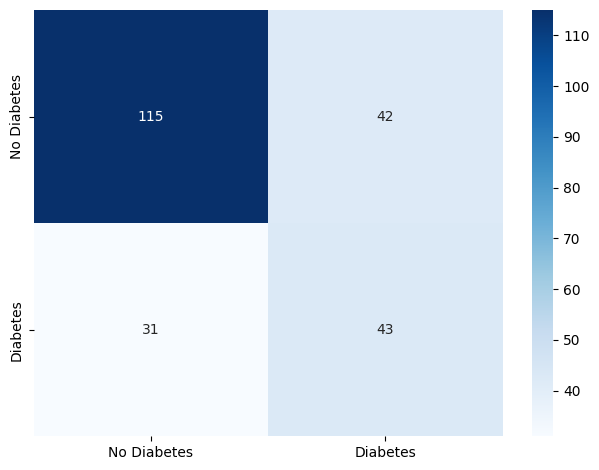

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

classes = ['No Diabetes','Diabetes']

print('TestConfusion matrix')
cf = confusion_matrix(y_pred_test,y_test)
sns.heatmap(cf,annot=True,yticklabels=classes,xticklabels=classes,cmap='Blues', fmt='g')
plt.tight_layout()
plt.show()

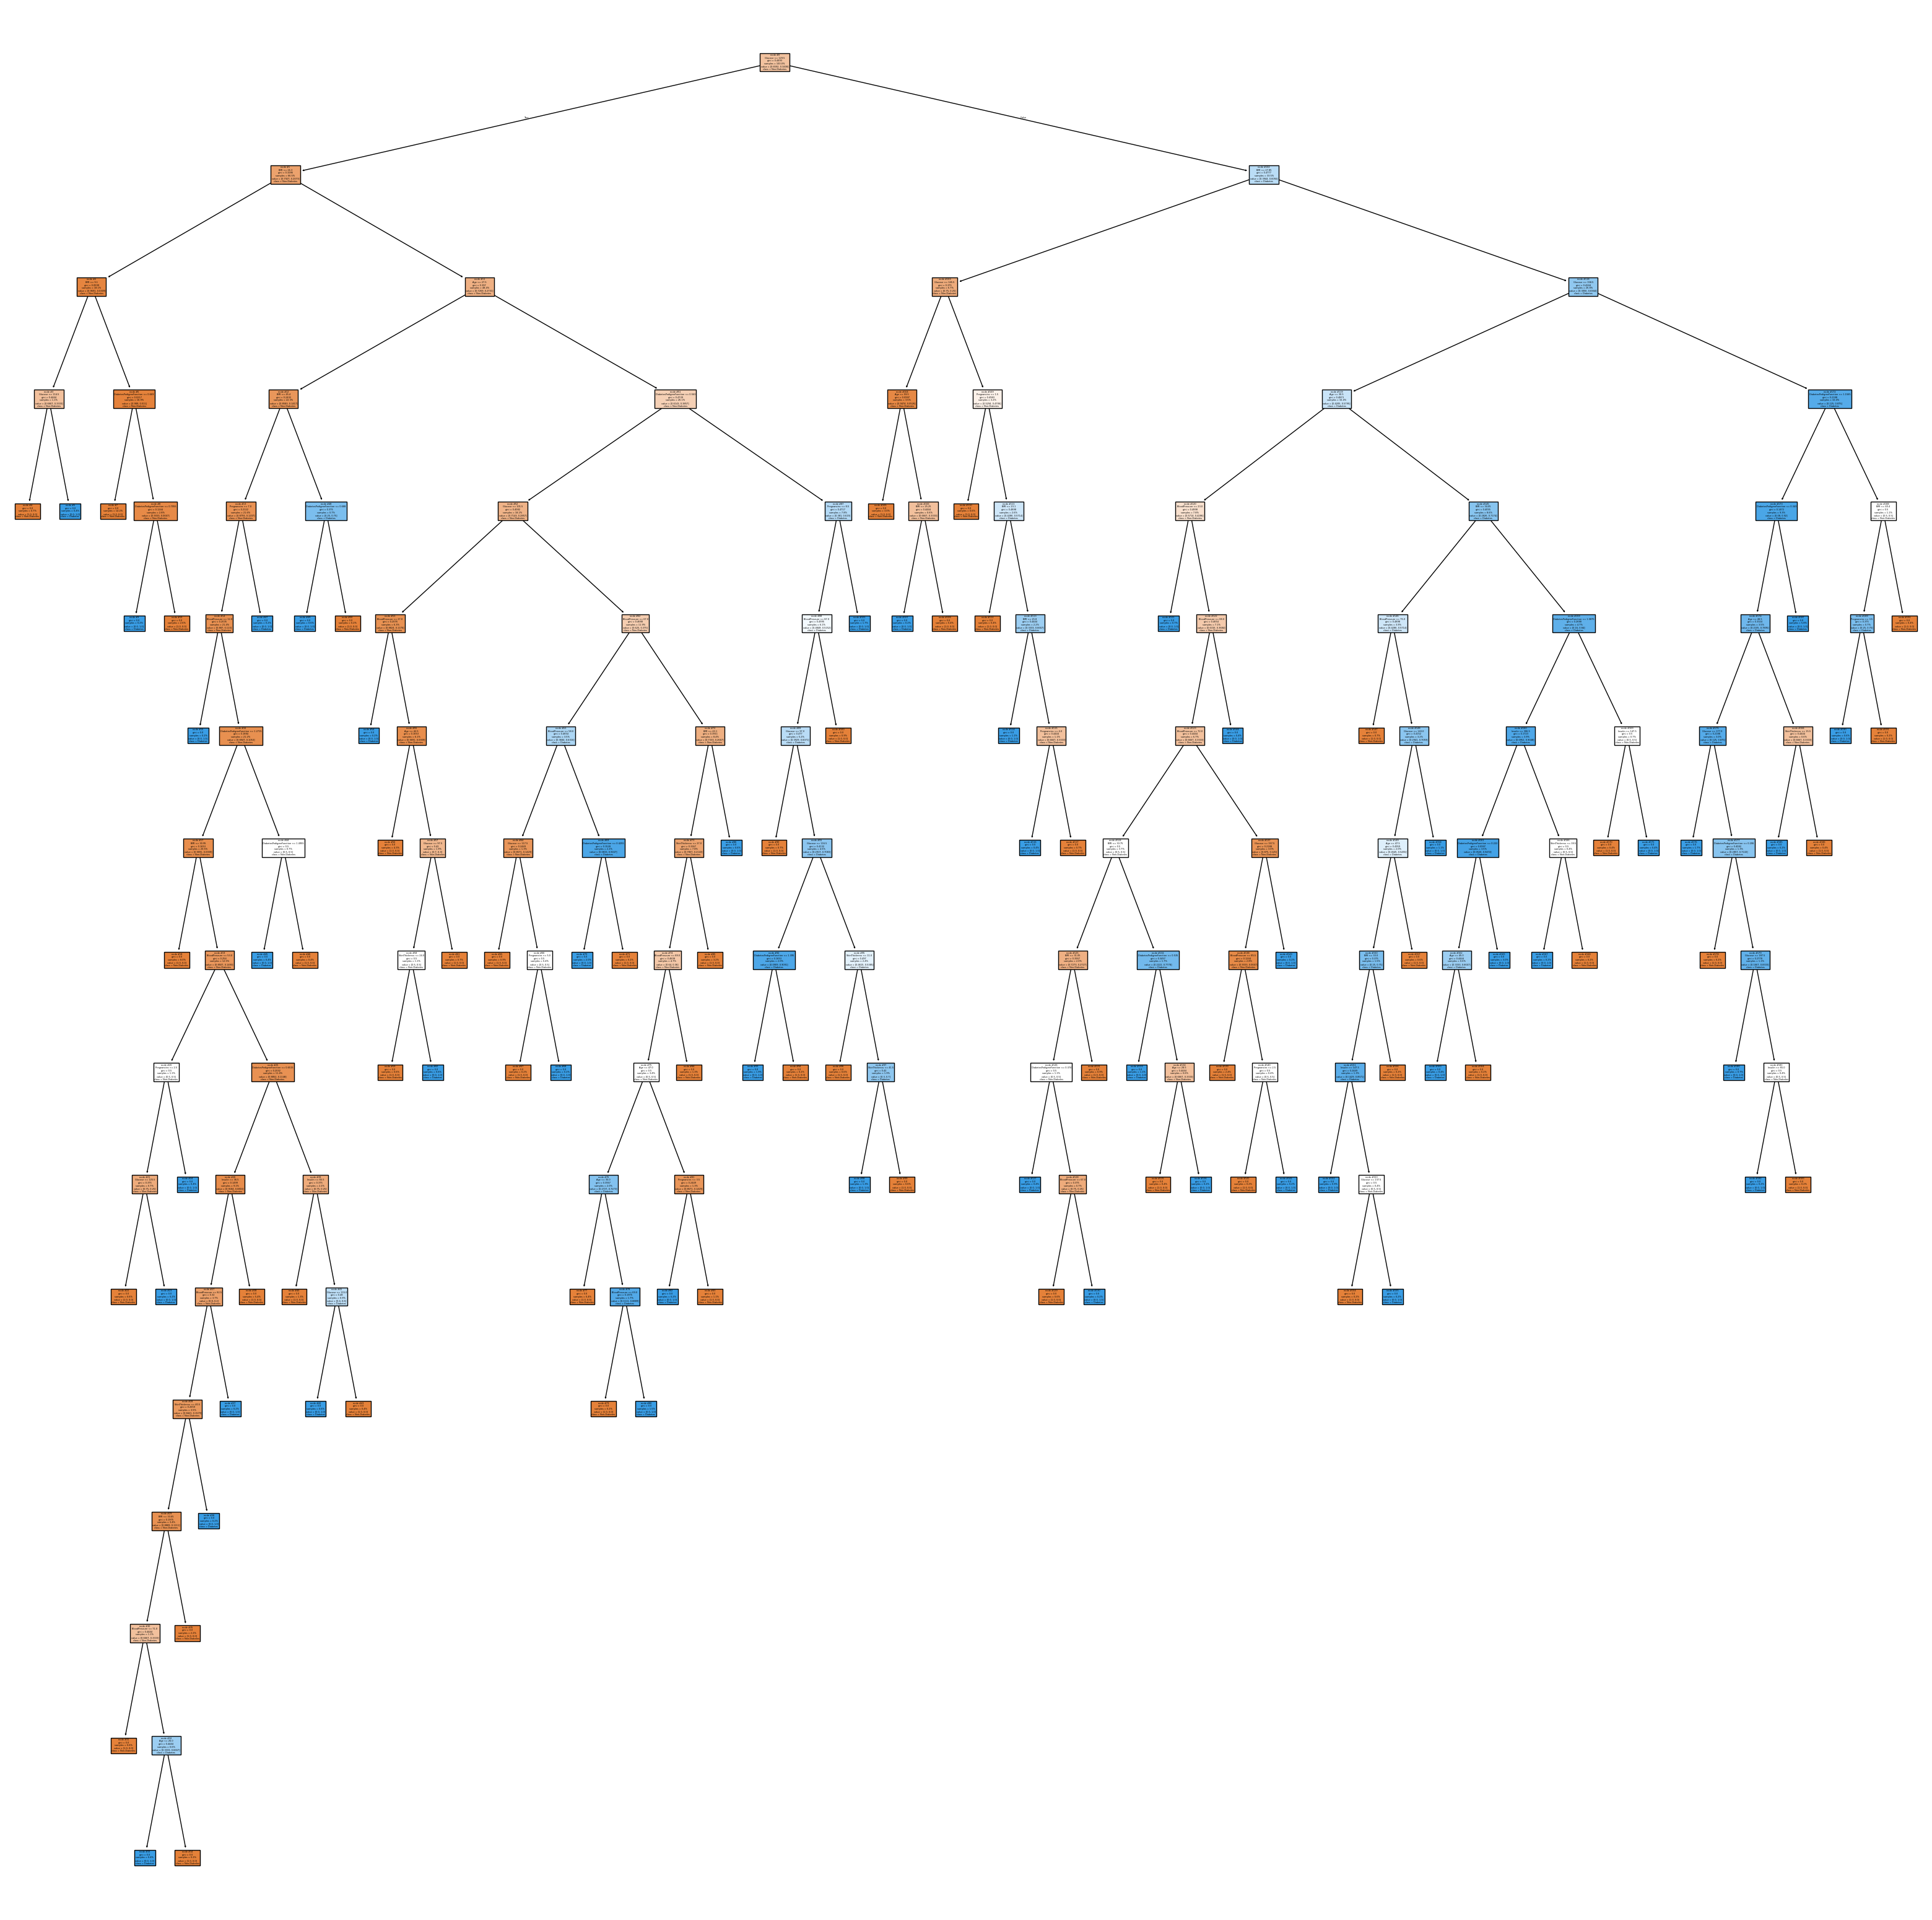

In [10]:
# Visualising the graph without the use of graphviz
# filled=True filles the color to indicate the majority class
# "precision" represents the number of decimal places needed for "gini"
# rounded:  When set to 'True', draw node boxes with rounded corners
# node_ids: When set to True, show the ID number on each node.
# proportion: When set to True, change the display of ‘values’ and/or ‘samples’ to be proportions and percentages respectively.

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize = (40,40))
dec_tree = plot_tree(decision_tree=dtree, feature_names = X.columns,
                     class_names =["Non-Diabetes", "Diabetes"] , filled = True , precision = 4,
                     rounded = False, node_ids=True, proportion=True)

plt.savefig("one.png")

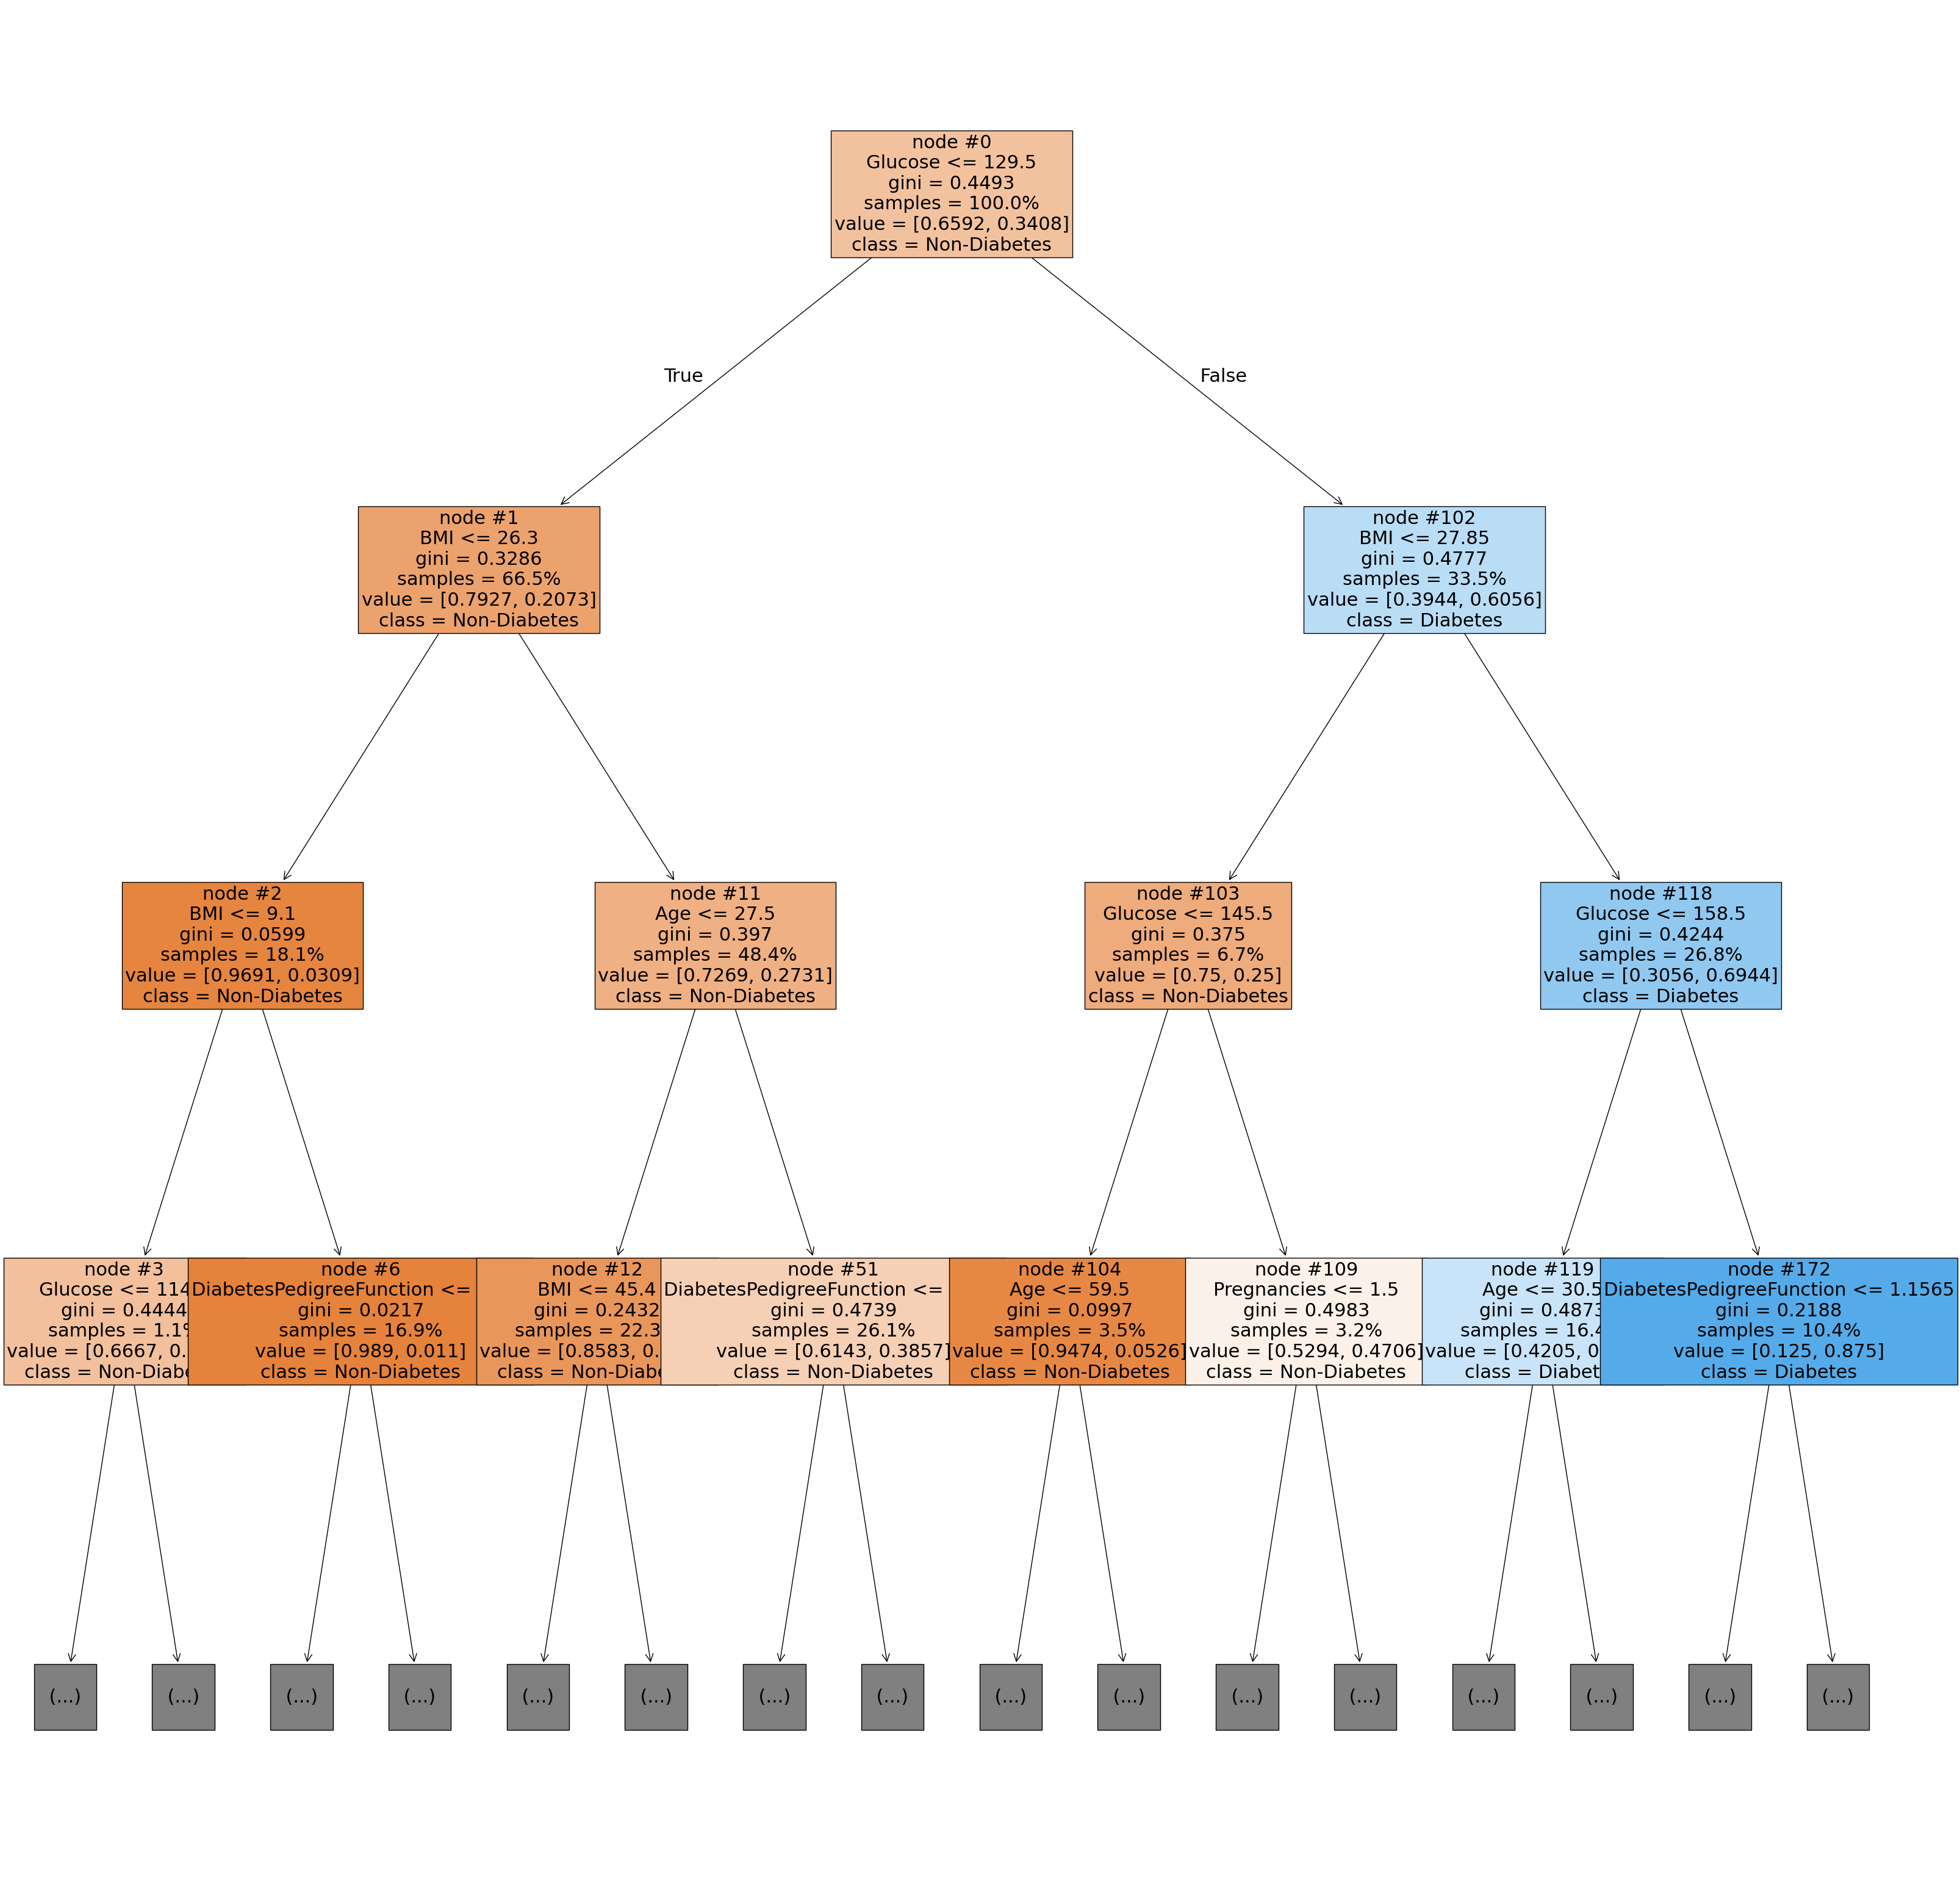

In [11]:
# Visualising the graph with only depth of "3"

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize = (40,40))
dec_tree = plot_tree(decision_tree=dtree, feature_names = X.columns,
                     class_names =["Non-Diabetes", "Diabetes"] , filled = True , precision = 4,
                     rounded = False, node_ids=True, proportion=True, max_depth=3, fontsize=22)

plt.savefig("one.png")

**Tuning the paramters using "GridSearchCV"**

In [12]:
from sklearn.model_selection import GridSearchCV

params = {'max_depth': [2,3,4,5,6,8,10,12],
         'min_samples_split': [4,6,8,10,12],
         'min_samples_leaf': [3,4,5,6,7,8]}


#Max_depth= 8, min sample split = 5, min sample leaf = 6
#Total model= 8*5*6 = 240

clf = DecisionTreeClassifier(random_state=0)
gcv = GridSearchCV(estimator=clf,param_grid=params)
gcv.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 3, ...], 'min_samples_leaf': [3, 4, ...], 'min_samples_split': [4, 6, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;-

In [13]:
#min_sample_leaf and min_sample_split may or may not come into picture depending upon if it is needed or not (Tree with small depth sometimes don't need these)
#Try running above code with only "10" and "12" as a depth and see how the results might change

dt_model = gcv.best_estimator_
dt_model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current nod

Train score 0.8026070763500931
Test score 0.7575757575757576
TestConfusion matrix


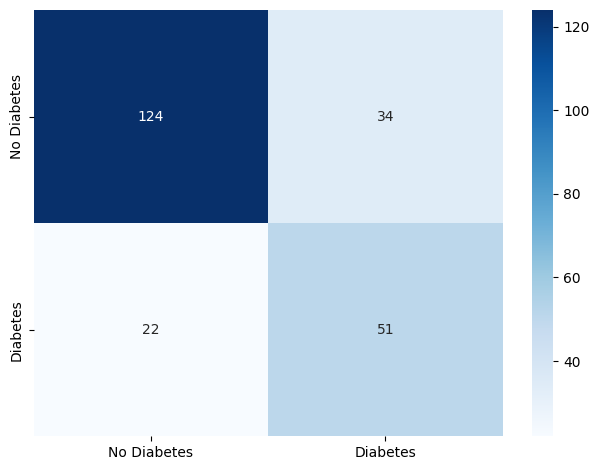

In [14]:
from sklearn.metrics import accuracy_score,confusion_matrix
import seaborn as sns
classes = ['No Diabetes','Diabetes']


dt_model.fit(X_train,y_train)

y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)

print(f'Train score {accuracy_score(y_train_pred,y_train)}')
print(f'Test score {accuracy_score(y_test_pred,y_test)}')

print('TestConfusion matrix')
cf = confusion_matrix(y_test_pred,y_test)
sns.heatmap(cf,annot=True,yticklabels=classes,xticklabels=classes,cmap='Blues', fmt='g')
plt.tight_layout()
plt.show()

#Earlier the train score was 100% and Test score ~68%
#Now our train score is 80% and test score is 77%

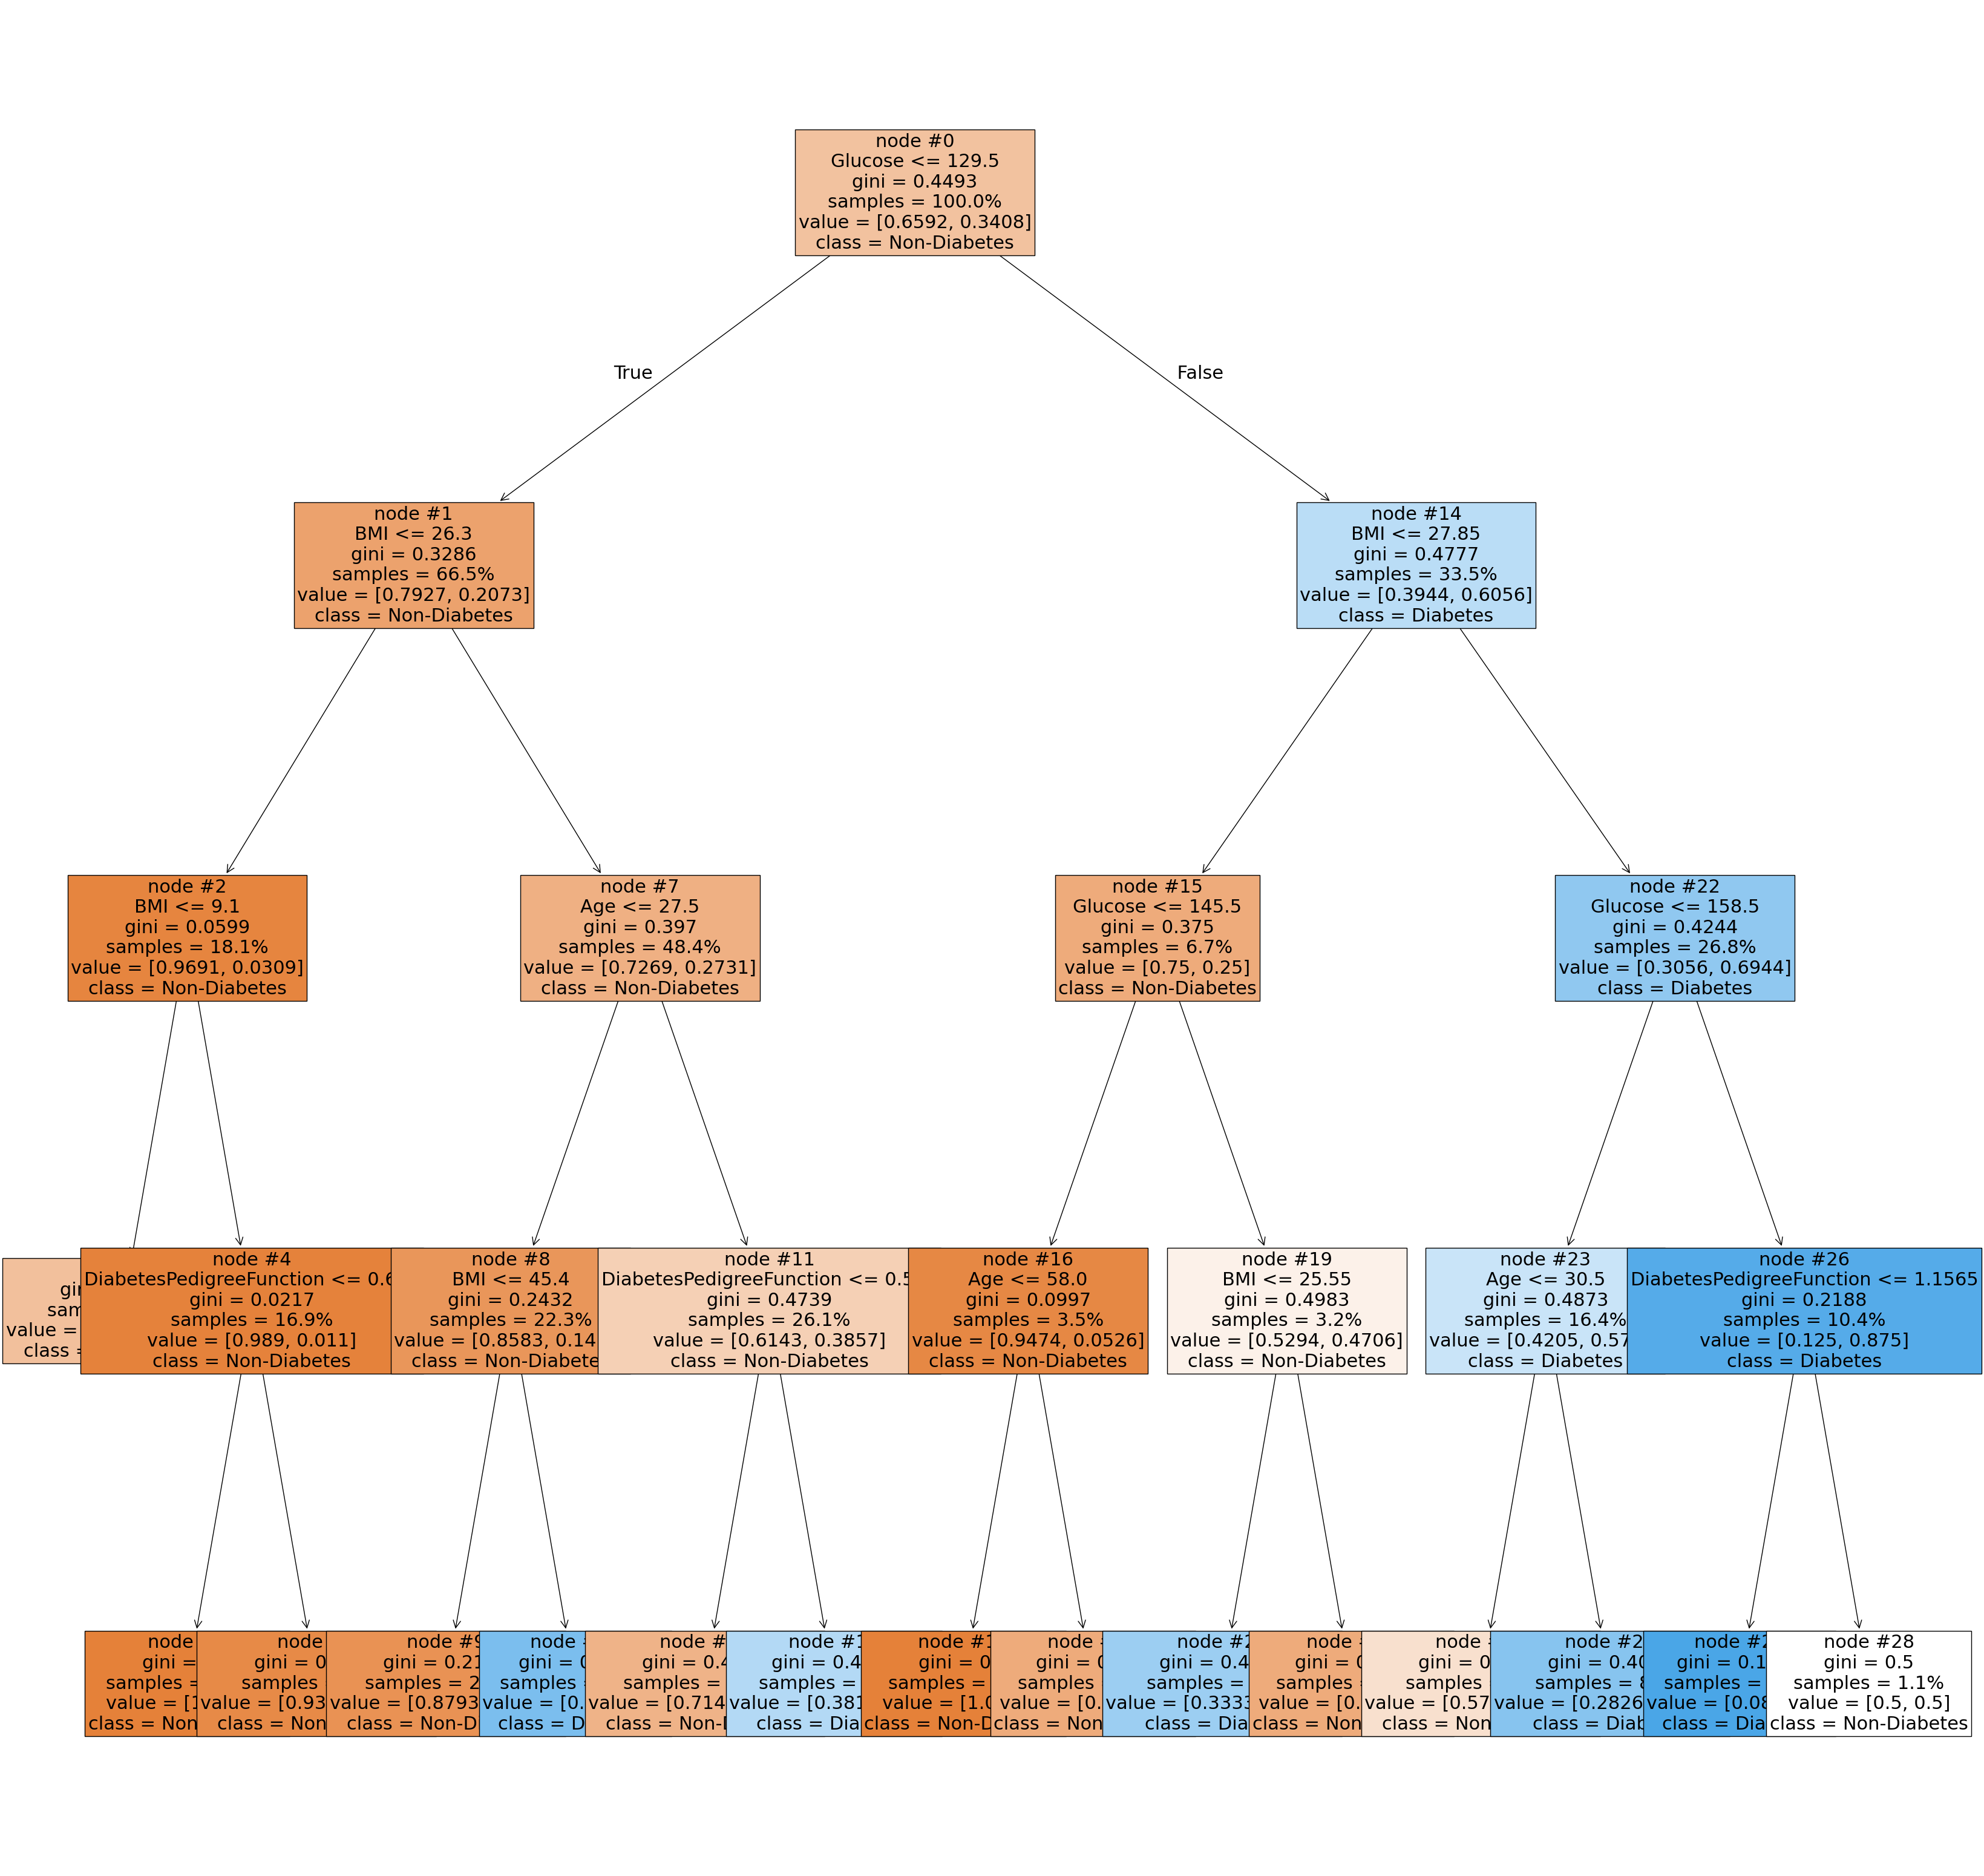

In [15]:
# Visualising the graph without the use of graphviz
# filled=True filles the color to indicate the majority class
# "precision" represents the number of decimal places needed for "gini"
# rounded:  When set to 'True', draw node boxes with rounded corners
# node_ids: When set to True, show the ID number on each node.
# proportion: When set to True, change the display of ‘values’ and/or ‘samples’ to be proportions and percentages respectively.

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize = (40,40))
dec_tree = plot_tree(decision_tree=dt_model, feature_names = X.columns,
                     class_names =["Non-Diabetes", "Diabetes"] , filled = True , precision = 4,
                     rounded = False, node_ids=True, proportion=True, fontsize=22)

plt.savefig("one.png")